### Create a map of Wolf Creek Pass to add to Portfolio post

#### Load mapping libraries

In [2]:
# Work with vector data
import geopandas as gpd

# Save maps and plots to files
import holoviews as hv
# Create interactive maps and plots
import hvplot.pandas

# Search for locations by name
from osmnx import features as osm

#### Search for point of interest 

In [42]:
center_point = (37.4831629,-106.803001)

# Search OSM features within 1000 m of the node
wolf_gdf = osm.features_from_point(
    center_point,
    tags={'natural':'saddle'},
    dist=1000
)

wolf_gdf

#wolf_gdf = wolf_gdf.loc[
    #wolf_gdf.index.get_level_values('element_type') == 'node'
#]

#wolf_gdf

,,geometry,ele,mountain_pass,name,natural,wikidata,wikipedia
element,id,,,,,,,
node,10154236080,POINT (-106.803 37.48316),3309,yes,Wolf Creek Pass,saddle,Q8029827,en:Wolf Creek Pass


<Axes: >

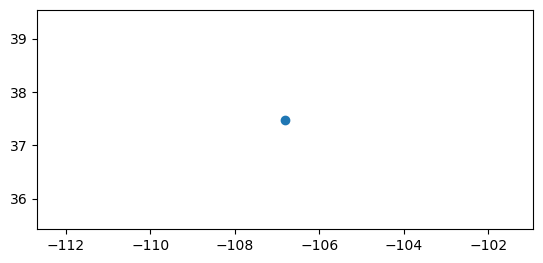

In [17]:
wolf_gdf.plot()

In [38]:
# Search for Mineral County

mineral_gdf = osm.features_from_address(
    'Mineral County, CO, United States',
    {'name': ['Mineral County']},
    dist=20000
)

mineral_gdf


# Keep only the Mineral County relation
#mineral_gdf = mineral_gdf.loc[
  #  mineral_gdf.index.get_level_values('element_type') == 'relation'
#]

,,geometry,name,wikidata,wikipedia,type,admin_level,alt_name,attribution,border_type,boundary,nist:fips_code,nist:state_fips,website
element,id,,,,,,,,,,,,,
relation,443692,"POLYGON ((-107.14428 37.7017, -107.14249 37.76...",Mineral County,Q312473,"en:Mineral County, Colorado",boundary,6,Mineral,USGS 2001 County Boundary,county,administrative,08079,08,https://www.mineralcountycolorado.com/


<Axes: >

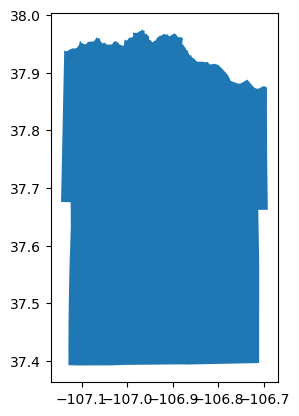

In [40]:
# simple plot of mineral county
mineral_gdf.plot()

In [46]:
# modify wolf gdf
wolf_gdf = gpd.GeoDataFrame(
    {
        'name': ['Wolf Creek Pass'],
        'latitude': [37.4831629],
        'longitude': [-106.803001]
    },
    geometry=gpd.points_from_xy(
        [-106.803001],
        [37.4831629]
    ),
    crs='EPSG:4326'
)

wolf_gdf

,name,latitude,longitude,geometry
0,Wolf Creek Pass,37.483163,-106.803001,POINT (-106.803 37.48316)


In [ ]:
# interactive map

# mineral county boundary
mineral_map = mineral_gdf.reset_index().hvplot(
    # Givethe map a descriptive title
    title="Mineral County",
    # Add a basemap
    geo=True, tiles='EsriImagery',
    # Change the colors
    fill_color='white', fill_alpha=0.2,
    line_color='darkred', line_width=5,
    # Change the image size
    frame_width=400, frame_height=400)




# great! that worked. now to add wolf creek pass as a node

mineral_map = mineral_map * wolf_gdf.hvplot.points(
    x='longitude',
    y='latitude',
    geo=True,
    color='red',
    size=10,
    marker='circle',
    hover_cols=['name']
)

mineral_map

# Save the map as a file to put on the web
hv.save(mineral_map, 'mineral.html')

# need to modify plot - color, point size and such 
